# Numerical simulation (no ROS, no PX4)

Replaces the original numerical studies (`rta_evanns*.ipynb` in tag `archive/main-2026-05-02`). Instead of
re-implementing the model inline, `px4_rta_mm_gpr.sim` runs the closed loop with **the node's own components**: the
same planar model, AOT-compiled early-exit rollouts (ground floor, GP feedforward), time-indexed RTA feedback, LQR
re-linearisation, the 9-row GP buffers and pre-emptive replanning. It writes the **same log format** as a flight, so
notebooks 01-03 work on these runs too.

The wind is the time-varying field of the original studies (GP profiles that drift every second), for the y-wind as a
function of altitude and the z-wind as a function of lateral position. The original values are accelerations of a
unit-mass model; `scale` converts them to forces for the 2 kg SITL vehicle (whose thrust authority is only about
+-2.2 m/s^2 around hover, so full-strength paper winds are not flyable).

In [1]:
import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

from px4_rta_mm_gpr import analysis as rta
rta.use_style()
pd.set_option('display.width', 200, 'display.max_columns', 30)
os.makedirs('figures', exist_ok=True)
from px4_rta_mm_gpr.sim import SimConfig, simulate, paper_winds, calm
os.makedirs('log_files/numerical', exist_ok=True)

## Scenarios

In [2]:
MASS = 2.0
scenarios = {'calm': calm(), 'paper winds x0.3': paper_winds(scale=0.3 * MASS),
             'paper winds x0.6': paper_winds(scale=0.6 * MASS), 'paper winds x1.0': paper_winds(scale=1.0 * MASS)}
results = {}
for name, winds in scenarios.items():
    path = 'log_files/numerical/' + name.replace(' ', '_').replace('.', 'p') + '.h5'
    results[name] = simulate(SimConfig(duration=20.0), winds=winds, log_path=path)
pd.DataFrame({k: r.summary for k, r in results.items()}).T[
    ['completed', 'stop_reason', 'simulated_time', 'final_error_to_goal', 'min_altitude', 'max_abs_theta_deg',
     'plans', 'uncertified_fraction', 'rollout_ms_median', 'wall_time_s']]

,completed,stop_reason,simulated_time,final_error_to_goal,min_altitude,max_abs_theta_deg,plans,uncertified_fraction,rollout_ms_median,wall_time_s
calm,True,None,19.99,0.003807,0.970979,28.058213,33,0.0,4.075811,4.825373
paper winds x0.3,True,None,19.99,0.20066,0.790954,26.509011,34,0.0,3.94666,4.65877
paper winds x0.6,True,None,19.99,0.316517,0.686508,36.822711,35,0.0,3.860884,4.753278
paper winds x1.0,True,None,19.99,0.470594,0.654811,43.409071,36,0.0,3.874623,4.605786


## Paths and certified tubes

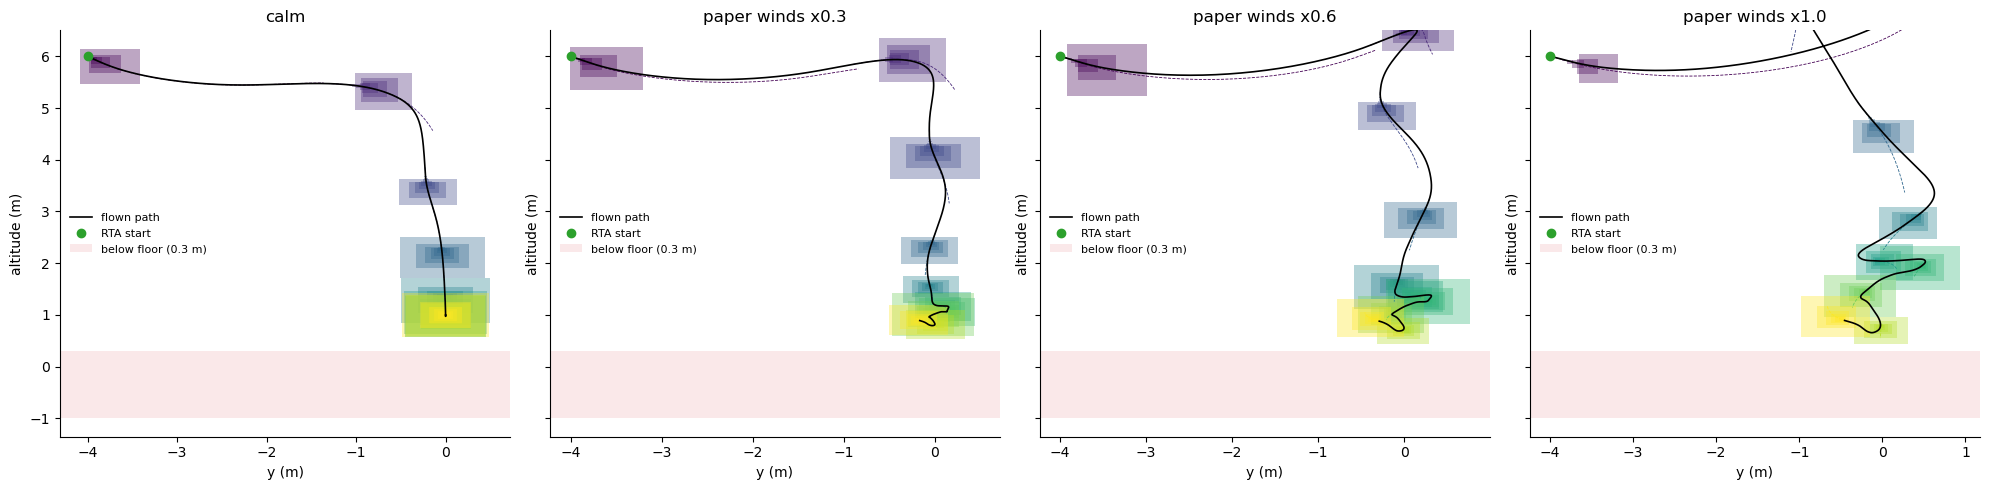

In [3]:
fig, axs = plt.subplots(1, len(results), figsize=(5 * len(results), 5), sharey=True)
for ax, (name, r) in zip(axs, results.items()):
    rta.plot_path(rta.load(r.log_path), ax=ax, n_tubes=10)
    ax.set_title(name)
fig.tight_layout(); fig.savefig('figures/numerical_paths.pdf')

## Animation (with the true wind for comparison)

In [4]:
name = 'paper winds x0.6'
outs = rta.animate(rta.load(results[name].log_path), 'figures/numerical_animation.mp4',
                   gif_path='figures/numerical_animation.gif', winds=paper_winds(scale=0.6 * MASS),
                   altitude_range=(-0.5, 8.0))
display(Markdown('![numerical animation](figures/numerical_animation.gif)  \n'
                 '[full-resolution MP4](figures/numerical_animation.mp4)'))

![numerical animation](figures/numerical_animation.gif)  
[full-resolution MP4](figures/numerical_animation.mp4)

## Early exit vs. full-horizon rollouts
The early-exit rollout stops at the certification point; the full rollout integrates the whole 30 s horizon. The
closed loop makes the same decisions (same plans, same rows) and agrees to floating-point rounding; only the compute
time differs.

In [5]:
cfg = dict(duration=6.0)
fast = simulate(SimConfig(**cfg, early_exit=True), winds=paper_winds(scale=0.6 * MASS))
full = simulate(SimConfig(**cfg, early_exit=False), winds=paper_winds(scale=0.6 * MASS))
same_plans = np.array_equal(fast.recorder.ticks.column('plan_seq'), full.recorder.ticks.column('plan_seq')) and     np.array_equal(fast.recorder.ticks.column('traj_idx'), full.recorder.ticks.column('traj_idx'))
diff = max(np.max(np.abs(fast.recorder.ticks.column(c) - full.recorder.ticks.column(c))) for c in ('y', 'z', 'thrust'))
print(f"same plan / row decisions at every tick: {same_plans}; states and commands agree to {diff:.1e} "
      f"(floating-point rounding: XLA fuses the while-loop and the scan differently)")
print(f"rollout median {fast.summary['rollout_ms_median']:.1f} ms (early exit) vs "
      f"{full.summary['rollout_ms_median']:.1f} ms (full 30 s horizon)")

same plan / row decisions at every tick: True; states and commands agree to 3.9e-14 (floating-point rounding: XLA fuses the while-loop and the scan differently)
rollout median 6.8 ms (early exit) vs 62.7 ms (full 30 s horizon)


## GP data collection: at every replan (original studies) vs. at 10 Hz (the node)

In [6]:
orig = simulate(SimConfig(duration=20.0, observe_period=None), winds=paper_winds(scale=0.6 * MASS))
node = results['paper winds x0.6']
pd.DataFrame({'observe at replans': orig.summary, 'observe at 10 Hz': node.summary}).T[
    ['completed', 'final_error_to_goal', 'min_altitude', 'plans', 'uncertified_fraction']]

,completed,final_error_to_goal,min_altitude,plans,uncertified_fraction
observe at replans,True,0.320707,0.718655,33,0.0
observe at 10 Hz,True,0.316517,0.686508,35,0.0
